# Modélisation LSTM pour la Prédiction du Prix du Maïs en Afrique

Modèle LSTM (PyTorch) avec normalisation par pays, séquence de 5 pas de temps, architecture simplifiée + BatchNorm + ReduceLROnPlateau.

## Bibliothèques

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch version: 2.12.0+cpu
Device: cpu


## 1. Chargement et Exploration des Données

In [166]:
dataset = pd.read_csv("./data/maize_final.csv")
print(len(dataset))
dataset.head()

734


,country,year,production_tonnes,yield_t_ha,area_harvested_ha,producer_price,production_growth_rate,production_ma3,production_deviation_from_ma3,production_intensity
0,Algeria,2001,1087.0,2717.5,400.0,63.33,-30.141388,1321.500000,-17.744987,2.717500
1,Algeria,2002,837.0,3348.0,250.0,62.88,-22.999080,1160.000000,-27.844828,3.348000
2,Algeria,2003,981.0,2885.3,340.0,66.91,17.204301,968.333333,1.308090,2.885294
3,Algeria,2004,679.0,3172.9,214.0,76.81,-30.784913,832.333333,-18.422107,3.172897
4,Algeria,2005,1148.0,3386.4,339.0,73.98,69.072165,936.000000,22.649573,3.386431


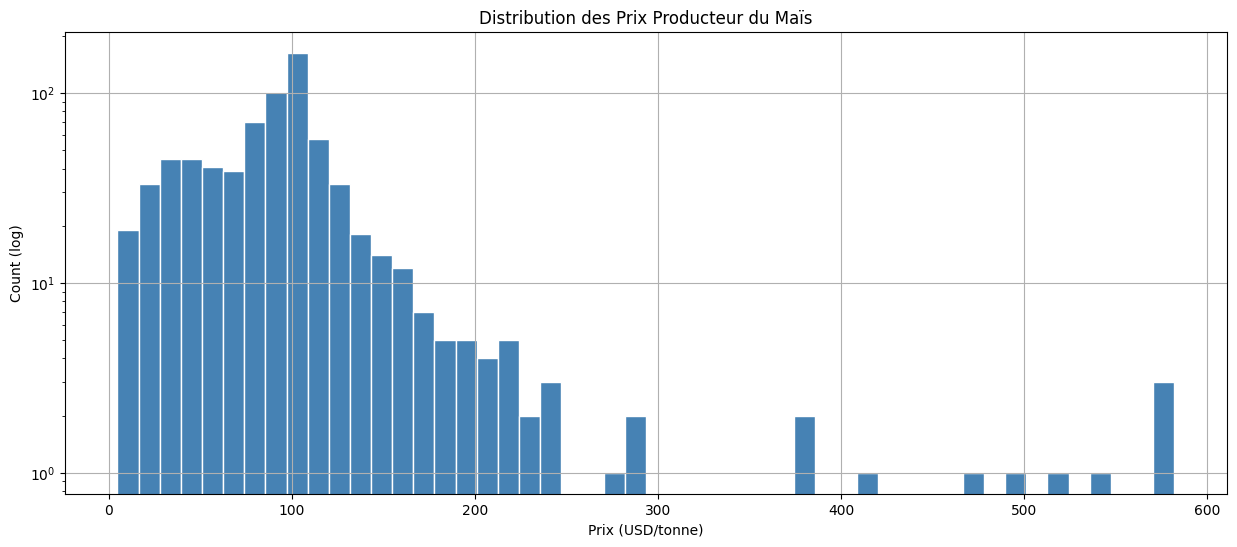

In [167]:
plt.figure(figsize=(15, 6))
plt.hist(dataset['producer_price'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.yscale('log')
plt.title("Distribution des Prix Producteur du Maïs")
plt.xlabel("Prix (USD/tonne)")
plt.ylabel("Count (log)")
plt.grid()
plt.show()

## 2. Preprocessing

### Encodage des pays

In [168]:
encoder = LabelEncoder()
dataset["country_encoded"] = encoder.fit_transform(dataset["country"])
dataset.head()

,country,year,production_tonnes,yield_t_ha,area_harvested_ha,producer_price,production_growth_rate,production_ma3,production_deviation_from_ma3,production_intensity,country_encoded
0,Algeria,2001,1087.0,2717.5,400.0,63.33,-30.141388,1321.500000,-17.744987,2.717500,0
1,Algeria,2002,837.0,3348.0,250.0,62.88,-22.999080,1160.000000,-27.844828,3.348000,0
2,Algeria,2003,981.0,2885.3,340.0,66.91,17.204301,968.333333,1.308090,2.885294,0
3,Algeria,2004,679.0,3172.9,214.0,76.81,-30.784913,832.333333,-18.422107,3.172897,0
4,Algeria,2005,1148.0,3386.4,339.0,73.98,69.072165,936.000000,22.649573,3.386431,0


### Features & Target

In [ ]:
dataset = dataset.sort_values(["country", "year"])
dataset["price_lag1"] = dataset.groupby("country")["producer_price"].shift(1)
dataset["price_lag2"] = dataset.groupby("country")["producer_price"].shift(2)

# Variation annuelle du prix (momentum)
dataset["price_delta"] = dataset.groupby("country")["producer_price"].diff()

features = [
    "country_encoded",
    "year",
    "production_tonnes",
    "yield_t_ha",
    "price_lag1",    # année précédente
    "price_lag2",    # il y a 2 ans
    "price_delta",   # variation annuelle
]

target = "producer_price"

print(dataset[features + [target]].isna().sum())

country_encoded       0
year                  0
production_tonnes     0
yield_t_ha            0
price_lag1           32
price_lag2           64
price_delta          32
producer_price        0
dtype: int64


In [ ]:
dataset = dataset.groupby("country", group_keys=False).apply(
    lambda g: g.fillna(method="ffill").fillna(method="bfill")
).reset_index(drop=True)

print(dataset[features + [target]].isna().sum())

country_encoded      0
year                 0
production_tonnes    0
yield_t_ha           0
price_lag1           0
price_lag2           0
price_delta          0
producer_price       0
dtype: int64


C:\Users\sonwa\AppData\Local\Temp\ipykernel_10976\468735723.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda g: g.fillna(method="ffill").fillna(method="bfill")
C:\Users\sonwa\AppData\Local\Temp\ipykernel_10976\468735723.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataset = dataset.groupby("country", group_keys=False).apply(


### Normalisation PAR PAYS

In [ ]:
scalers_per_country = {}

dataset_normalized = dataset.copy()

countries = dataset["country"].unique()
features_to_scale = [f for f in features if f != "country_encoded"]

for country in countries:
    mask = dataset_normalized["country"] == country
    country_data = dataset_normalized.loc[mask, features_to_scale + [target]].copy()

    scaler = MinMaxScaler()
    country_data[features_to_scale + [target]] = scaler.fit_transform(
        country_data[features_to_scale + [target]]
    )

    dataset_normalized.loc[mask, features_to_scale + [target]] = country_data[features_to_scale + [target]].values
    scalers_per_country[country] = scaler

# Normaliser country_encoded
ce_scaler = MinMaxScaler()
dataset_normalized["country_encoded"] = ce_scaler.fit_transform(
    dataset_normalized[["country_encoded"]]
)

print(f"Scalers créés pour {len(scalers_per_country)} pays")
dataset_normalized[features + [target]].describe()

Scalers créés pour 32 pays

C:\Users\sonwa\AppData\Local\Temp\ipykernel_10976\950660686.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.         0.04347826 0.08695652 0.13043478 0.17391304 0.2173913
 0.26086957 0.30434783 0.34782609 0.39130435 0.43478261 0.47826087
 0.52173913 0.56521739 0.60869565 0.65217391 0.69565217 0.73913043
 0.7826087  0.82608696 0.86956522 0.91304348 0.95652174 1.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataset_normalized.loc[mask, features_to_scale + [target]] = country_data[features_to_scale + [target]].values


,country_encoded,year,production_tonnes,yield_t_ha,price_lag1,price_lag2,price_delta,producer_price
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,0.503911,0.500000,0.382668,0.499755,0.397069,0.384283,0.481999,0.414758
std,0.295234,0.301928,0.326591,0.302374,0.314374,0.314648,0.243820,0.312333
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.258065,0.250000,0.069218,0.248893,0.124067,0.108152,0.339655,0.134390
50%,0.483871,0.500000,0.328833,0.469031,0.339731,0.323542,0.475750,0.359409
75%,0.774194,0.750000,0.668433,0.757859,0.651254,0.634738,0.616391,0.677984
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Création des séquences (SEQUENCE_LENGTH = 5)

In [172]:
SEQUENCE_LENGTH = 5

X = []
y = []

for country in countries:
    country_data = dataset_normalized[
        dataset_normalized["country"] == country
    ].sort_values("year")

    values = country_data[features + [target]].values

    if len(values) <= SEQUENCE_LENGTH:
        continue

    for i in range(len(values) - SEQUENCE_LENGTH):
        seq = values[i:i + SEQUENCE_LENGTH]
        target_value = values[i + SEQUENCE_LENGTH, -1]
        X.append(seq[:, :-1])
        y.append(target_value)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (576, 5, 7)
y shape: (576,)


### Train / Test Split (temporel — pas de shuffle)

In [173]:
split = int(len(X) * 0.8)

train_x, test_x = X[:split], X[split:]
train_y, test_y = y[:split], y[split:]

print("Train X shape:", train_x.shape)
print("Train Y shape:", train_y.shape)
print("Test X shape:", test_x.shape)
print("Test Y shape:", test_y.shape)

Train X shape: (460, 5, 7)
Train Y shape: (460,)
Test X shape: (116, 5, 7)
Test Y shape: (116,)


### Dataset & DataLoader PyTorch

In [174]:
class MaizeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = MaizeDataset(train_x, train_y)
test_dataset  = MaizeDataset(test_x,  test_y)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 15
Test  batches : 4


## 3. Modèle LSTM (PyTorch)

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super(LSTMModel, self).__init__()

        # LSTM bidirectionnel
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True,
        )
        lstm_out_size = hidden_size * 2

        # Mécanisme d'attention simple sur les pas de temps
        self.attention = nn.Linear(lstm_out_size, 1)

        self.bn   = nn.BatchNorm1d(lstm_out_size)
        self.drop = nn.Dropout(dropout)

        # Tête de régression
        self.fc1 = nn.Linear(lstm_out_size, 32)
        self.act  = nn.ReLU()
        self.fc2  = nn.Linear(32, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = (attn_weights * lstm_out).sum(dim=1)

        out = self.bn(context)
        out = self.drop(out)
        out = self.act(self.fc1(out))
        out = self.fc2(out)
        return out


input_size = train_x.shape[2]
model = LSTMModel(input_size=input_size).to(device)
print(model)
print(f"\nParamètres entraînables : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

LSTMModel(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Linear(in_features=128, out_features=1, bias=True)
  (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (act): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

Paramètres entraînables : 141,250


## 4. Entraînement

In [ ]:
import os
os.makedirs('./model', exist_ok=True)

criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

EPOCHS        = 100
PATIENCE      = 20
best_val_loss  = float("inf")
patience_counter = 0
best_weights   = None
train_losses   = []
val_losses     = []

# Séparation train / val temporelle (80/20 du train)
val_size = int(0.2 * len(train_x))
tr_x = torch.tensor(train_x[:-val_size], dtype=torch.float32)
tr_y = torch.tensor(train_y[:-val_size], dtype=torch.float32).unsqueeze(1)
vl_x = torch.tensor(train_x[-val_size:], dtype=torch.float32).to(device)
vl_y = torch.tensor(train_y[-val_size:], dtype=torch.float32).unsqueeze(1).to(device)

tr_loader = DataLoader(
    torch.utils.data.TensorDataset(tr_x, tr_y),
    batch_size=16, shuffle=False
)

for epoch in range(1, EPOCHS + 1):

    # Train
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in tr_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        # Gradient clipping → évite les explosions de gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(tr_x)

    # Validation
    model.eval()
    with torch.no_grad():
        val_preds = model(vl_x)
        val_loss  = criterion(val_preds, vl_y).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(best_weights, "./model/best_model_weights.pt")
    else:
        patience_counter += 1

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping à l'epoch {epoch}")
        break

model.load_state_dict(best_weights)
print("\nMeilleurs poids restaurés.")

Epoch  20/300 | Train: 0.024984 | Val: 0.023002 | LR: 1.00e-03

Early stopping à l'epoch 28

Meilleurs poids restaurés.


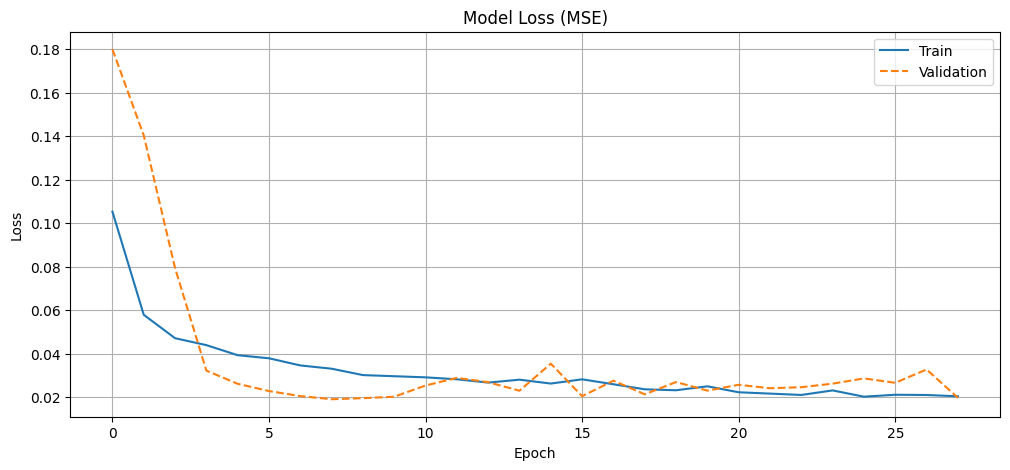

In [177]:
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation', linestyle='--')
plt.title('Model Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid()
plt.show()

## 5. Évaluation

In [178]:
model.eval()

all_preds = []
all_true  = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).cpu().numpy().flatten()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy().flatten())

predictions_scaled = np.array(all_preds)
test_y_scaled      = np.array(all_true)

print(f"Prédictions shape : {predictions_scaled.shape}")

Prédictions shape : (116,)


In [ ]:
# Reconstruire les labels pays pour chaque point test
all_country_labels = []
for country in countries:
    country_data = dataset_normalized[
        dataset_normalized["country"] == country
    ].sort_values("year")
    n = len(country_data) - SEQUENCE_LENGTH
    if n > 0:
        all_country_labels.extend([country] * n)

test_country_labels = all_country_labels[split:]

# Inverse transform par pays
features_to_scale = [f for f in features if f != "country_encoded"]
n_cols = len(features_to_scale) + 1   # features scalées + target

true_prices_real = []
pred_prices_real = []

for i, country in enumerate(test_country_labels):
    scaler = scalers_per_country[country]

    dummy_true = np.zeros((1, n_cols))
    dummy_pred = np.zeros((1, n_cols))
    dummy_true[0, -1] = test_y_scaled[i]
    dummy_pred[0, -1] = predictions_scaled[i]

    true_prices_real.append(scaler.inverse_transform(dummy_true)[0, -1])
    pred_prices_real.append(scaler.inverse_transform(dummy_pred)[0, -1])

true_prices_real = np.array(true_prices_real)
pred_prices_real = np.array(pred_prices_real)

mae  = mean_absolute_error(true_prices_real, pred_prices_real)
mse  = mean_squared_error(true_prices_real, pred_prices_real)
rmse = np.sqrt(mse)
r2   = r2_score(true_prices_real, pred_prices_real)

print(f"MAE  : {mae:.2f} USD/tonne")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f} USD/tonne")
print(f"R²   : {r2:.4f}")

MAE  : 22.39 USD/tonne
MSE  : 860.58
RMSE : 29.34 USD/tonne
R²   : 0.3560


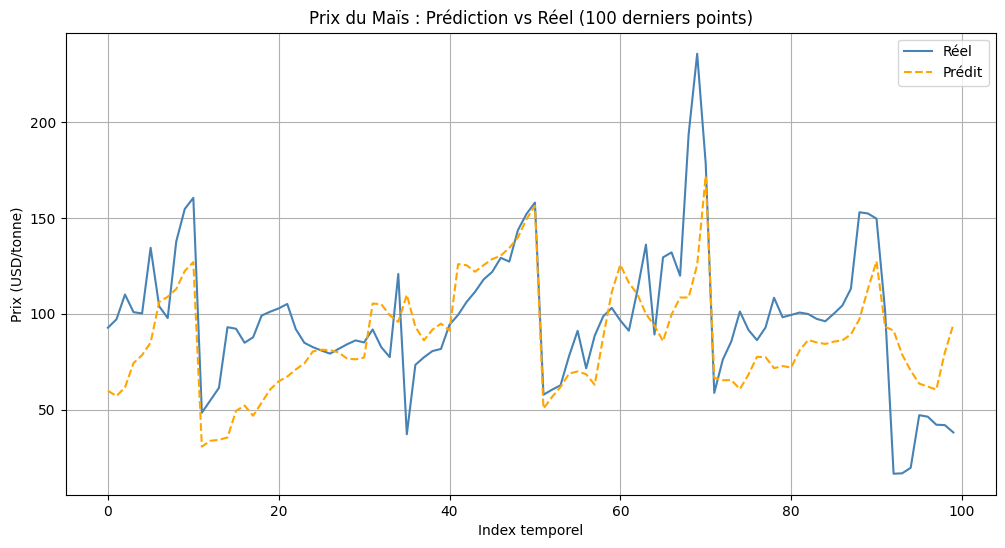

In [180]:
plt.figure(figsize=(12, 6))
plt.plot(true_prices_real[-100:], label='Réel',  color='steelblue')
plt.plot(pred_prices_real[-100:], label='Prédit', color='orange', linestyle='--')
plt.title('Prix du Maïs : Prédiction vs Réel (100 derniers points)')
plt.xlabel('Index temporel')
plt.ylabel('Prix (USD/tonne)')
plt.legend()
plt.grid()
plt.show()

## 6. Forecast Multi-Années


Forecast Cameroon (2025 → 2030) :
  2025 → 114.16 USD/tonne
  2026 → 116.58 USD/tonne
  2027 → 119.74 USD/tonne
  2028 → 122.87 USD/tonne
  2029 → 125.10 USD/tonne
  2030 → 126.26 USD/tonne


C:\Users\sonwa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\sonwa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\sonwa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\sonwa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\

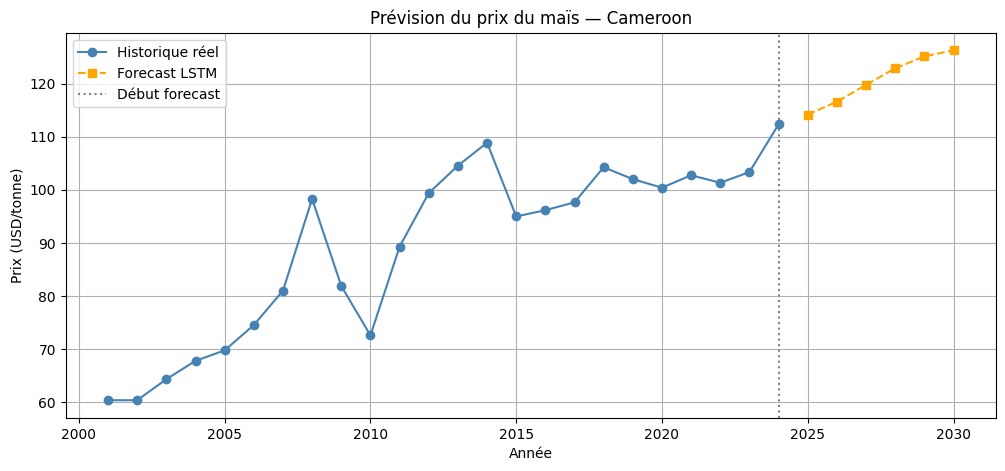

In [ ]:
country = "Cameroon"
annee   = 2030

scaler = scalers_per_country[country]
features_to_scale = [f for f in features if f != "country_encoded"]
n_cols = len(features_to_scale) + 1

country_data_norm = dataset_normalized[
    dataset_normalized["country"] == country
].sort_values("year")

last_known_year = int(dataset[dataset["country"] == country]["year"].max())

if len(country_data_norm) < SEQUENCE_LENGTH:
    print("Pas assez de données pour la séquence")
elif annee <= last_known_year:
    print(f"Choisir une année > {last_known_year}")
else:
    # Séquence initiale = les SEQUENCE_LENGTH dernières années connues
    sequence     = country_data_norm[features].values[-SEQUENCE_LENGTH:].copy()
    year_col_idx = features.index("year")

    # Scaler global pour normaliser l'année correctement
    from sklearn.preprocessing import MinMaxScaler as _MMS
    _ys = _MMS()
    _ys.fit(dataset[["year"]])

    model.eval()
    predictions_forecast = []

    for year in range(last_known_year + 1, annee + 1):
        input_tensor = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            pred_scaled = model(input_tensor).cpu().numpy()[0, 0]

        # Inverse transform → vrai prix USD/tonne
        dummy = np.zeros((1, n_cols))
        dummy[0, -1] = pred_scaled
        predicted_value = scaler.inverse_transform(dummy)[0, -1]
        predictions_forecast.append((year, predicted_value))

        # Mise à jour séquence
        new_row = sequence[-1].copy()

        # 1. Année : normalisée via scaler global
        new_row[year_col_idx] = _ys.transform([[year]])[0, 0]

        # 2. Glisser la fenêtre d'un pas
        sequence = np.vstack([sequence[1:], new_row])

    print(f"\nForecast {country} ({last_known_year + 1} → {annee}) :")
    for y, val in predictions_forecast:
        print(f"  {y} → {val:.2f} USD/tonne")

    # Visualisation avec historique réel en fond
    hist = dataset[dataset["country"] == country].sort_values("year")

    years_fc  = [p[0] for p in predictions_forecast]
    prices_fc = [p[1] for p in predictions_forecast]

    plt.figure(figsize=(12, 5))
    plt.plot(hist["year"], hist["producer_price"],
             marker="o", color="steelblue", label="Historique réel")
    plt.plot(years_fc, prices_fc,
             marker="s", linestyle="--", color="orange", label="Forecast LSTM")
    plt.axvline(x=last_known_year, color="gray", linestyle=":", label="Début forecast")
    plt.title(f"Prévision du prix du maïs — {country}")
    plt.xlabel("Année")
    plt.ylabel("Prix (USD/tonne)")
    plt.legend()
    plt.grid()
    plt.show()

## 8. Sauvegarde

In [ ]:
import joblib

# Sauvegarder le modèle PyTorch
torch.save(model.state_dict(), "./model/model_africa_maize.pt")

# Sauvegarder architecture (pour recharger facilement)
torch.save(model, "./model/model_africa_maize_full.pt")

# Sauvegarder scalers et encodeur
joblib.dump(scalers_per_country, "./model/scalers_per_country.save")
joblib.dump(encoder,             "./model/country_encoder.save")

print("Modèle et scalers sauvegardés")

Modèle et scalers sauvegardés avec succès.
